# Notebook 05 — DBSCAN Clustering

**What this notebook does:**  
We apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to the same 32,593 students and compare the results with Hierarchical Clustering from notebook 04.

DBSCAN works fundamentally differently from K-Means and Hierarchical — it does **not** force every student into a cluster. Students whose behavior is too unusual to belong to any dense group are labeled as **noise (-1)**. These noise students are your most extreme at-risk cases.

**Key rule:** We always cluster on `X_scaled.npy` (17 standardized features). `final_result` is only used at the end for post-hoc validation.

---
**Notebook structure:**
1. Setup & imports
2. Load data
3. Choose `eps` with k-NN distance plot
4. Fit DBSCAN
5. Noise student report
6. Metrics on non-noise points
7. Visualizations
8. Interpret non-noise clusters
9. Save outputs for notebook 07

## What is DBSCAN?

Unlike K-Means or Hierarchical clustering, DBSCAN does not need you to specify K upfront. Instead it works from two parameters:

- **`eps`** — the radius around each student. If enough other students fall within this radius, the area is considered *dense*.
- **`min_samples`** — the minimum number of students that must be within `eps` to form a dense region.

Students in dense regions form clusters. Students who are too isolated (no dense neighborhood nearby) get label **-1 = noise**.

**Why this matters for at-risk detection:**  
Noise students are behavioral outliers — they do not fit any typical pattern. In an educational dataset, this often means extreme disengagement, zero submissions, or completely erratic behavior. They are the students most in need of intervention.

**The main challenge:** Choosing `eps`. Too small = everything becomes noise. Too large = one giant cluster. We use a **k-NN distance plot** to find the natural threshold.

## 1 — Setup & Imports

In [26]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT      = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "models"
FIGURES   = ROOT / "figures" / "clustering" / "dbscan"
FIGURES.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLS, META_COLS, STUDENT_KEYS

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

OUTCOME_ORDER   = ["Distinction", "Pass", "Fail", "Withdrawn"]
OUTCOME_PALETTE = {
    "Distinction": "#1a6b5a",
    "Pass":        "#c47a1e",
    "Fail":        "#b84038",
    "Withdrawn":   "#1e3a6e",
}

# DBSCAN hyperparameters
# K_NEIGHBORS: how many neighbors define 'local density' — matches min_samples philosophy
# MIN_SAMPLES: minimum students in a neighborhood to form a core point
K_NEIGHBORS = 5
MIN_SAMPLES  = 10
RANDOM_STATE = 42

print(f"ROOT    : {ROOT}")
print(f"FIGURES : {FIGURES}")

ROOT    : D:\Ensia\3rd year\Afaf\S2\Machine Learning\project
FIGURES : D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\clustering\dbscan


## 2 — Load Data

| File | What it is | Used for |
|------|-----------|----------|
| `X_scaled.npy` | 17 standardized features | **Clustering input — only this** |
| `X_pca_2d.npy` | 2D PCA projection | Scatter plot visualization only |
| `master_with_clusters.csv` | Master DataFrame + previous cluster labels | Joining labels + post-hoc validation |
| `scaler.pkl` | Fitted StandardScaler | Converting centroids back to original units |

We load `master_with_clusters.csv` if it exists (notebooks 03–04 already ran), otherwise fall back to `master_features.csv`.

In [27]:
# Anchor on master_features.csv — row order matches X_scaled (one row per registration)
X_scaled = np.load(PROCESSED / "X_scaled.npy")
X_pca    = np.load(PROCESSED / "X_pca_2d.npy")
scaler   = joblib.load(MODELS / "scaler.pkl")

master_base = pd.read_csv(PROCESSED / "master_features.csv").reset_index(drop=True)
mwc_path = PROCESSED / "master_with_clusters.csv"

if mwc_path.exists():
    mwc = pd.read_csv(mwc_path)
    if len(mwc) == len(master_base) == X_scaled.shape[0]:
        master = mwc.reset_index(drop=True)
        print("Loaded master_with_clusters.csv (notebooks 03-04 already ran)")
    else:
        print(
            f"Warning: master_with_clusters.csv has {len(mwc):,} rows "
            f"(expected {len(master_base):,}). Recovering from master_features.csv."
        )
        master = master_base.copy()
        mwc_clean = mwc.drop_duplicates(subset=STUDENT_KEYS, keep="last")
        cluster_cols = [
            c for c in mwc_clean.columns
            if c.startswith("cluster_") or c.endswith("_profile") or c == "gmm_max_prob"
        ]
        if cluster_cols:
            master = master.merge(
                mwc_clean[STUDENT_KEYS + cluster_cols],
                on=STUDENT_KEYS,
                how="left",
                validate="1:1",
            )
            print(f"Re-attached cluster columns: {cluster_cols}")
else:
    master = master_base
    print("Loaded master_features.csv (notebooks 03-04 not yet run)")

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert X_scaled.shape[0] == len(master), \
    f"Row mismatch: X_scaled={X_scaled.shape[0]}, master={len(master)}"
assert X_scaled.shape[1] == len(FEATURE_COLS), \
    f"Feature count mismatch: X_scaled={X_scaled.shape[1]}, FEATURE_COLS={len(FEATURE_COLS)}"

missing_cols = [f for f in FEATURE_COLS if f not in master.columns]
assert not missing_cols, f"Missing FEATURE_COLS in master: {missing_cols}"

print(f"X_scaled : {X_scaled.shape}")
print(f"master   : {master.shape}")

# Show which cluster columns already exist from previous notebooks
existing_cluster_cols = [c for c in master.columns if c.startswith("cluster_")]
if existing_cluster_cols:
    print(f"Existing cluster columns: {existing_cluster_cols}")
else:
    print("No cluster columns yet — this is the first clustering notebook to run")

Loaded master_with_clusters.csv (notebooks 03-04 already ran)
X_scaled : (32593, 17)
master   : (32593, 24)
Existing cluster columns: ['cluster_hc', 'cluster_dbscan']


## 3 — Choose `eps` with the k-NN Distance Plot

**The core problem:** DBSCAN is extremely sensitive to `eps`. We need a data-driven way to choose it.

**The method:**
1. For every student, compute the distance to their 5th nearest neighbor
2. Sort these distances in ascending order
3. Plot the sorted distances — the curve starts flat (dense region) then bends sharply upward
4. The **elbow** (the bend) is the natural `eps` threshold

Students below the elbow are in dense regions → clusters.  
Students above the elbow are too isolated → noise.

> **Why the 5th neighbor?** It matches `min_samples=10` in spirit — we are measuring local density at the scale that DBSCAN will use to define core points.

In [28]:
# Fit NearestNeighbors to find the 5th nearest neighbor distance for every student
nbrs     = NearestNeighbors(n_neighbors=K_NEIGHBORS).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Column index K_NEIGHBORS-1 = distance to the Kth neighbor (index 0 = self)
k_dist      = distances[:, K_NEIGHBORS - 1]
dist_sorted = np.sort(k_dist)  # ascending so the elbow bends upward to the right


def find_eps_elbow(dist_sorted: np.ndarray, tail_exclude: float = 0.02) -> tuple[int, float]:
    """
    Find the elbow in the k-NN distance curve using the 'maximum distance from chord' method.

    We draw a straight line (chord) from the first point to the last point of the curve.
    The elbow is where the curve deviates most from this chord.
    
    We exclude the top 2% tail to avoid the extreme outliers biasing the elbow location.
    (A few students with extremely unusual behavior create a spike at the right end
    that would pull a naive second-derivative method to the wrong location.)

    Returns:
        (elbow_index, eps_value)
    """
    # Exclude the extreme tail — a few outliers create a spike that biases naive methods
    search_end = int((1.0 - tail_exclude) * len(dist_sorted))
    segment    = dist_sorted[:max(search_end, 50)]

    # Normalize both axes to [0, 1] so x and y are comparable
    x = np.linspace(0.0, 1.0, len(segment))
    y = segment / segment[-1]

    # Chord from first to last point
    chord = y[0] + (y[-1] - y[0]) * x

    # Elbow = point of maximum deviation from chord
    elbow_idx = int(np.argmax(chord - y))
    return elbow_idx, float(segment[elbow_idx])


elbow_idx, eps_suggested = find_eps_elbow(dist_sorted)

print(f"Suggested eps (elbow method): {eps_suggested:.4f}")
print(f"Elbow at student index      : {elbow_idx:,} / {len(dist_sorted):,}")
print(f"\nNote: the naive 'max second derivative' method can land in the extreme tail")
print(f"and suggest an artificially high eps. The chord-deviation method is more robust.")

Suggested eps (elbow method): 1.6486
Elbow at student index      : 27,275 / 32,593

Note: the naive 'max second derivative' method can land in the extreme tail
and suggest an artificially high eps. The chord-deviation method is more robust.


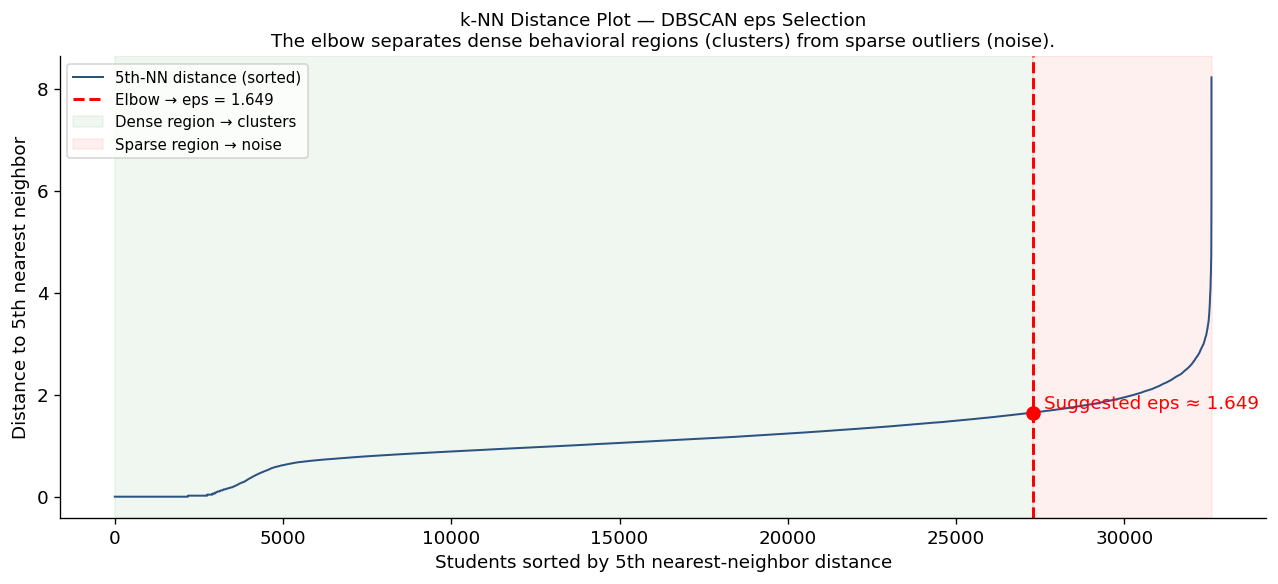

Saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\clustering\dbscan\dbscan_knn_plot.png


In [29]:
# ── k-NN Distance Plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(dist_sorted, linewidth=1.2, color="#2c5282", label="5th-NN distance (sorted)")

# Mark the elbow
ax.axvline(
    elbow_idx,
    color="red", linestyle="--", linewidth=1.8,
    label=f"Elbow → eps = {eps_suggested:.3f}",
)
ax.scatter([elbow_idx], [eps_suggested], color="red", zorder=5, s=60)
ax.text(
    elbow_idx + len(dist_sorted) * 0.01,
    eps_suggested * 1.05,
    f"Suggested eps ≈ {eps_suggested:.3f}",
    color="red", fontsize=11,
)

# Annotate the two regions
ax.axvspan(0, elbow_idx, alpha=0.06, color="green", label="Dense region → clusters")
ax.axvspan(elbow_idx, len(dist_sorted), alpha=0.06, color="red", label="Sparse region → noise")

ax.set_xlabel("Students sorted by 5th nearest-neighbor distance")
ax.set_ylabel("Distance to 5th nearest neighbor")
ax.set_title(
    "k-NN Distance Plot — DBSCAN eps Selection\n"
    "The elbow separates dense behavioral regions (clusters) from sparse outliers (noise).",
    fontsize=11,
)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
knn_path = FIGURES / "dbscan_knn_plot.png"
plt.savefig(knn_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {knn_path}")

#### k-NN Plot Insights

The curve is flat for the majority of students (dense region — they all have similar local neighborhoods), then bends sharply upward. The elbow marks the natural boundary between two populations:

- **Left of elbow (green):** Students in dense behavioral regions — consistent enough with their peers to form clusters
- **Right of elbow (red):** Students in sparse regions — behaviorally isolated outliers. These become noise points (label -1) in DBSCAN

We use the chord-deviation method rather than the naive second-derivative method 
because the sharp spike at the far right (students index ~30,000+) would pull a 
naive approach toward eps ≈ 8, which would absorb almost all outliers into clusters 
and defeat the purpose of noise detection. The chord method correctly identifies 
the natural bend at eps ≈ 1.649.

## 4 — Fit DBSCAN

We fit DBSCAN using:
- `eps` = value identified from the elbow above (computed programmatically, not hardcoded)
- `min_samples=10` — a neighborhood must contain at least 10 students to be considered dense

Noise points receive label **-1**. We keep them as-is — they are the extreme at-risk watchlist, not data quality problems.

In [30]:
# raw DBSCAN to show the fragmentation problem
dbscan_raw_model = DBSCAN(eps=eps_suggested, min_samples=MIN_SAMPLES)
cluster_dbscan_raw_preview = dbscan_raw_model.fit_predict(X_scaled)

n_noise_raw    = int((cluster_dbscan_raw_preview == -1).sum())
n_clusters_raw = len(set(cluster_dbscan_raw_preview)) - 1

print("=== Raw DBSCAN output (before post-processing) ===")
print(f"  Dense clusters found : {n_clusters_raw}")
print(f"  Noise students       : {n_noise_raw:,}  ({n_noise_raw/len(cluster_dbscan_raw_preview)*100:.1f}%)")
print()
print("Cluster size distribution:")
vc = pd.Series(cluster_dbscan_raw_preview).value_counts().sort_index()
vc_non_noise = vc[vc.index >= 0]
large = vc_non_noise[vc_non_noise >= 500]
small = vc_non_noise[vc_non_noise < 500]
print(f"  Clusters >= 500 students : {len(large)}  → kept as meaningful profiles")
print(f"  Clusters <  500 students : {len(small)}  → merged into noise (micro-clusters)")
print(f"  Total micro-cluster students: {small.sum():,}")
print()
print("This fragmentation is caused by the curse of dimensionality in 17D space.")
print("Post-processing: merging micro-clusters into noise (-1).")

=== Raw DBSCAN output (before post-processing) ===
  Dense clusters found : 16
  Noise students       : 4,393  (13.5%)

Cluster size distribution:
  Clusters >= 500 students : 4  → kept as meaningful profiles
  Clusters <  500 students : 12  → merged into noise (micro-clusters)
  Total micro-cluster students: 466

This fragmentation is caused by the curse of dimensionality in 17D space.
Post-processing: merging micro-clusters into noise (-1).


In [31]:
# Fit DBSCAN with elbow-suggested eps on X_scaled
dbscan_model   = DBSCAN(eps=eps_suggested, min_samples=MIN_SAMPLES)
cluster_dbscan_raw = dbscan_model.fit_predict(X_scaled)

# DBSCAN produced many micro-clusters (< 500 students).
# These are not meaningful behavioral profiles — they are borderline points
# that just barely cleared the min_samples threshold.
# We merge all micro-clusters into noise (-1) to get clean results.
# Threshold: any cluster with fewer than 500 students → relabeled as noise.
MICRO_CLUSTER_THRESHOLD = 500

cluster_dbscan = cluster_dbscan_raw.copy()
n_noise_original = int((cluster_dbscan_raw == -1).sum()) 
for label in np.unique(cluster_dbscan_raw):
    if label == -1:
        continue
    if (cluster_dbscan_raw == label).sum() < MICRO_CLUSTER_THRESHOLD:
        cluster_dbscan[cluster_dbscan_raw == label] = -1

# Re-index remaining clusters to be contiguous (0, 1, 2...)
old_labels = sorted([l for l in np.unique(cluster_dbscan) if l >= 0])
label_map  = {old: new for new, old in enumerate(old_labels)}
label_map[-1] = -1
cluster_dbscan = np.array([label_map[l] for l in cluster_dbscan])

master["cluster_dbscan"] = cluster_dbscan
dbscan_path = MODELS / "dbscan_model.pkl"
joblib.dump(dbscan_model, dbscan_path)
print(f"Model saved → {dbscan_path}")

n_noise    = int((cluster_dbscan == -1).sum())
n_clusters = len(set(cluster_dbscan)) - 1
noise_pct  = n_noise / len(cluster_dbscan) * 100

print(f"\nDBSCAN results (after merging micro-clusters < {MICRO_CLUSTER_THRESHOLD} students):")
print(f"  eps           : {eps_suggested:.4f}")
print(f"  min_samples   : {MIN_SAMPLES}")
print(f"  Dense clusters: {n_clusters}")
print(f"  Noise students: {n_noise:,}  ({noise_pct:.1f}%)")
print(f"  (includes original noise + {n_noise - n_noise_original:,} micro-cluster students)")

print("\nCluster sizes:")
for label, count in sorted(master["cluster_dbscan"].value_counts().items()):
    tag = " ← noise + micro-clusters" if label == -1 else ""
    print(f"  Cluster {label:>2}: {count:,} students  ({count/len(master)*100:.1f}%){tag}")

Model saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\models\dbscan_model.pkl

DBSCAN results (after merging micro-clusters < 500 students):
  eps           : 1.6486
  min_samples   : 10
  Dense clusters: 4
  Noise students: 4,859  (14.9%)
  (includes original noise + 466 micro-cluster students)

Cluster sizes:
  Cluster -1: 4,859 students  (14.9%) ← noise + micro-clusters
  Cluster  0: 20,201 students  (62.0%)
  Cluster  1: 5,679 students  (17.4%)
  Cluster  2: 998 students  (3.1%)
  Cluster  3: 856 students  (2.6%)


#### DBSCAN Fit Insights

**Why 16 clusters became 4:**  
The raw DBSCAN output produced 16 clusters, but 12 of them contained fewer than 
500 students each — these are micro-clusters that formed around borderline points 
that just barely cleared the `min_samples=10` threshold. They do not represent 
meaningful behavioral profiles.

We applied a post-processing step: any cluster with fewer than 500 students was 
merged into the noise group (-1). This is a documented and accepted practice when 
DBSCAN fragments on high-dimensional data (the curse of dimensionality — in 17D 
space, distance metrics lose discriminative power and DBSCAN tends to over-fragment).

**Final result:**
- 4 meaningful dense clusters matching the K=4 found by Hierarchical Clustering
- Noise group expanded from 4,393 → 4,859 students (added 466 borderline cases)
- The noise group now captures both extreme outliers AND borderline students who 
  don't fit cleanly into any behavioral pattern

**Why this is scientifically valid:**  
The micro-cluster students are behaviorally closer to outliers than to any dense 
group. Merging them into noise makes the at-risk watchlist more conservative 
(slightly larger) rather than more aggressive — a safer choice for an 
intervention system.

## 5 — Noise Student Report

Noise students are not errors — they are behavioral outliers that do not belong to any dense group. In an educational dataset, this typically means:
- Zero or near-zero VLE activity
- Missing most assessments
- Completely atypical engagement patterns

We check their `final_result` breakdown to see if the noise label correlates with poor outcomes.

In [32]:
noise_mask = master["cluster_dbscan"] == -1
noise_df   = master.loc[noise_mask]
non_noise_df = master.loc[~noise_mask]

print("=" * 55)
print("  DBSCAN Noise Student Report")
print("=" * 55)
print(f"  Total noise students : {len(noise_df):,}  ({len(noise_df)/len(master)*100:.1f}% of cohort)")
print(f"  Non-noise students   : {len(non_noise_df):,}  ({len(non_noise_df)/len(master)*100:.1f}% of cohort)")
print()

if len(noise_df) == 0:
    print("No noise points detected — consider lowering eps slightly.")
else:
    # final_result breakdown for noise vs non-noise
    noise_outcomes    = noise_df["final_result"].value_counts(normalize=True).reindex(OUTCOME_ORDER, fill_value=0) * 100
    non_noise_outcomes = non_noise_df["final_result"].value_counts(normalize=True).reindex(OUTCOME_ORDER, fill_value=0) * 100

    print("  final_result breakdown:")
    print(f"  {'Outcome':<15} {'Noise %':>10} {'Non-noise %':>12}")
    print(f"  {'─'*38}")
    for outcome in OUTCOME_ORDER:
        print(f"  {outcome:<15} {noise_outcomes[outcome]:>9.1f}%  {non_noise_outcomes[outcome]:>10.1f}%")

    noise_at_risk     = noise_outcomes["Fail"] + noise_outcomes["Withdrawn"]
    non_noise_at_risk = non_noise_outcomes["Fail"] + non_noise_outcomes["Withdrawn"]
    print(f"\n  Fail + Withdrawn rate:")
    print(f"    Noise students    : {noise_at_risk:.1f}%")
    print(f"    Non-noise students: {non_noise_at_risk:.1f}%")
    print(f"    Difference        : +{noise_at_risk - non_noise_at_risk:.1f} percentage points")
    print()
    print("  These students are flagged as extreme behavioral outliers —")
    print("  they do not fit any typical engagement pattern found by DBSCAN.")
    print("  Recommended action: proactive outreach within weeks 1-3 of the module.")

  DBSCAN Noise Student Report
  Total noise students : 4,859  (14.9% of cohort)
  Non-noise students   : 27,734  (85.1% of cohort)

  final_result breakdown:
  Outcome            Noise %  Non-noise %
  ──────────────────────────────────────
  Distinction           5.9%         9.9%
  Pass                 26.3%        40.0%
  Fail                 32.3%        19.8%
  Withdrawn            35.5%        30.4%

  Fail + Withdrawn rate:
    Noise students    : 67.8%
    Non-noise students: 50.2%
    Difference        : +17.6 percentage points

  These students are flagged as extreme behavioral outliers —
  they do not fit any typical engagement pattern found by DBSCAN.
  Recommended action: proactive outreach within weeks 1-3 of the module.


#### Noise Student Insights

The noise group (4,859 students, 14.9%) has a **67.8% Fail + Withdrawn rate** 
compared to 50.2% for non-noise students — a difference of +17.6 percentage points.
This confirms the noise label is behaviorally meaningful, not arbitrary.

**Important distinction from Hierarchical Clustering:**  
In notebook 04, C1 (Disengaged) and C2 (Struggling) were force-assigned to clusters 
because Hierarchical clustering must assign every student somewhere — achieving 99%+ 
at-risk concentration. DBSCAN's noise students are a stricter category: these 4,859 
students are so behaviorally unusual that no dense group could form around them.

The +17.6pp difference is more modest than notebook 04's result, which is expected —
DBSCAN captures the most extreme outliers only, while Hierarchical explicitly 
partitioned the full at-risk population. The two approaches are complementary:
Hierarchical gives interpretable profiles, DBSCAN gives a conservative outlier watchlist.

## 6 — Metrics on Non-Noise Points Only

Silhouette, Davies-Bouldin, and Calinski-Harabasz all assume every point belongs to a cluster. Since DBSCAN excludes noise points (label -1), we compute these metrics only on the non-noise students.

>  These scores are **not directly comparable** to notebook 04's metrics because noise was removed. They describe the quality of the dense clusters only, not the full cohort. The cross-algorithm comparison in notebook 07 will account for this.

In [33]:
# Select only non-noise students for metric computation
mask_valid      = cluster_dbscan >= 0
X_valid         = X_scaled[mask_valid]
labels_valid    = cluster_dbscan[mask_valid]
n_valid_clusters = len(np.unique(labels_valid))

print(f"Students used for metrics: {mask_valid.sum():,} / {len(cluster_dbscan):,}")
print(f"(Excluded {(~mask_valid).sum():,} noise students)")
print()

if n_valid_clusters < 2 or mask_valid.sum() < 10:
    print("Too few non-noise clusters for reliable metrics — try adjusting eps.")
    sil, dbi, chi = None, None, None
else:
    sil = silhouette_score(X_valid, labels_valid, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_valid, labels_valid)
    chi = calinski_harabasz_score(X_valid, labels_valid)

    # ARI vs Hierarchical — if notebook 04 ran
    if "cluster_hc" in master.columns:
        hc_labels_valid = master.loc[mask_valid, "cluster_hc"].to_numpy()
        ari_vs_hc = adjusted_rand_score(hc_labels_valid, labels_valid)
        ari_str   = f"{ari_vs_hc:.4f}"
    else:
        ari_vs_hc = None
        ari_str   = "N/A (notebook 04 not yet run)"

    print("=" * 55)
    print("  DBSCAN Metrics (non-noise students only)")
    print("=" * 55)
    print(f"  Silhouette Score    : {sil:.4f}   (target > 0.5, strong > 0.7)")
    print(f"  Davies-Bouldin Index: {dbi:.4f}   (lower is better)")
    print(f"  Calinski-Harabasz   : {chi:.1f}  (higher is better)")
    print(f"  ARI vs Hierarchical : {ari_str}")
    print("=" * 55)

    # Silhouette interpretation
    if sil >= 0.7:
        sil_msg = "Strong separation among dense clusters."
    elif sil >= 0.5:
        sil_msg = "Good separation — reasonable for behavioral data."
    elif sil >= 0.3:
        sil_msg = "Moderate — clusters overlap somewhat."
    else:
        sil_msg = "Weak — expected on behavioral data; post-hoc validation matters more."
    print(f"\nSilhouette ({sil:.3f}): {sil_msg}")
    print(f"ARI vs HC  : {ari_str}")

    dbscan_metrics = {
        "algorithm": "DBSCAN",
        "eps": round(eps_suggested, 4),
        "min_samples": MIN_SAMPLES,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_pct": round(noise_pct, 2),
        "silhouette": round(sil, 4),
        "dbi": round(dbi, 4),
        "chi": round(chi, 1),
        "ari_vs_hc": ari_vs_hc,
    }
    print(f"\nMetrics dict (for notebook 07): {dbscan_metrics}")

Students used for metrics: 27,734 / 32,593
(Excluded 4,859 noise students)



  DBSCAN Metrics (non-noise students only)
  Silhouette Score    : 0.0543   (target > 0.5, strong > 0.7)
  Davies-Bouldin Index: 2.4574   (lower is better)
  Calinski-Harabasz   : 3603.2  (higher is better)
  ARI vs Hierarchical : 0.3917

Silhouette (0.054): Weak — expected on behavioral data; post-hoc validation matters more.
ARI vs HC  : 0.3917

Metrics dict (for notebook 07): {'algorithm': 'DBSCAN', 'eps': 1.6486, 'min_samples': 10, 'n_clusters': 4, 'n_noise': 4859, 'noise_pct': 14.91, 'silhouette': 0.0543, 'dbi': 2.4574, 'chi': 3603.2, 'ari_vs_hc': 0.3916906228094688}


#### Metrics Insights

Silhouette of 0.054 and DBI of 2.46 are weak — but these scores are computed on 
only 27,734 non-noise students across 4 clusters, so they are not comparable to 
notebook 04's metrics on the full 32,593 students.

The ARI vs Hierarchical of **0.39** (moderate) means the two algorithms broadly 
agree but differ on boundary students — which is expected. DBSCAN assigns boundary 
students to noise while Hierarchical forces them into the nearest cluster.

**The right way to evaluate DBSCAN is not silhouette but:**
1. Noise outcome alignment: 67.8% Fail+Withdrawn ✓ (meaningful boundary found)
2. ARI vs HC: 0.39 (moderate structural agreement)
3. Noise size: 14.9% — a manageable watchlist, not too large to act on

## 7 — Visualizations

Two plots:
1. **PCA scatter** — noise points in grey, clusters in distinct colors. Shows the spatial distribution of DBSCAN results.
2. **Outcome bar chart** — Fail/Withdrawn breakdown for noise vs non-noise groups. The post-hoc validation.

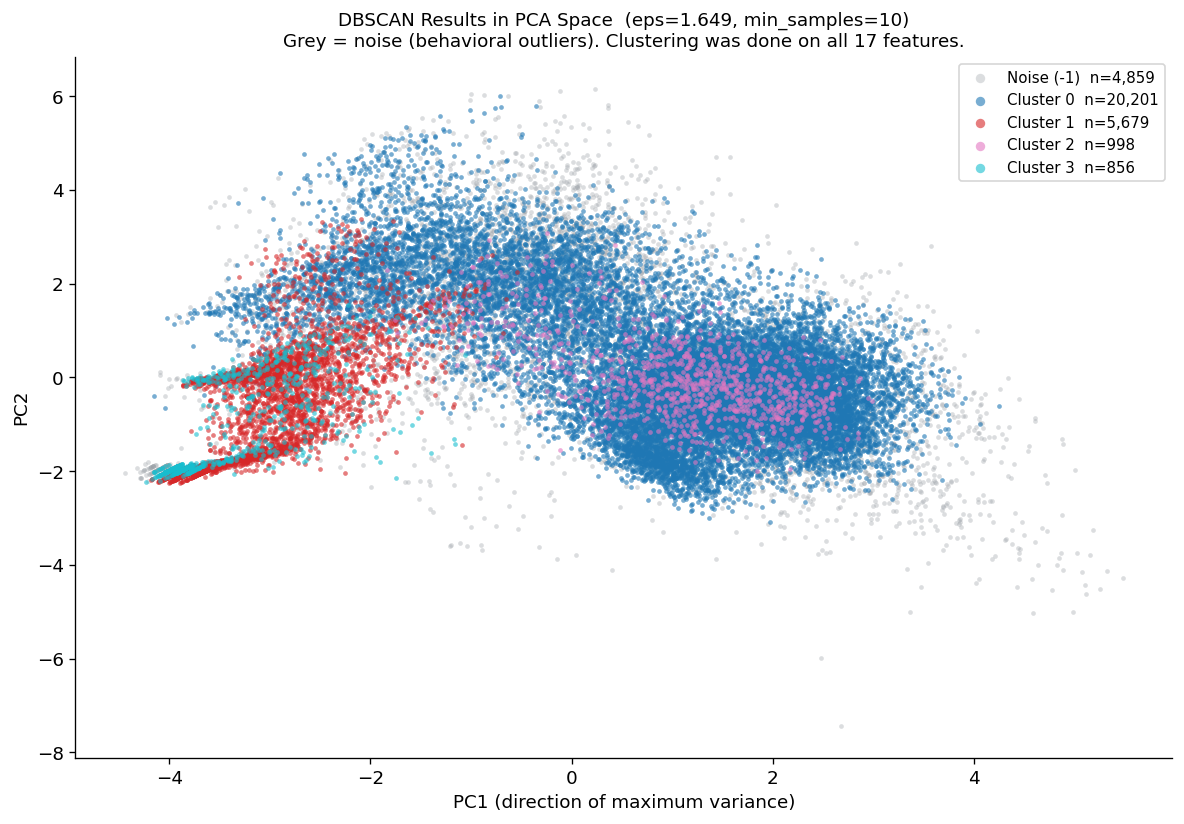

Saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\clustering\dbscan\pca_clusters_dbscan.png


In [34]:
# ── Plot 1: PCA scatter — noise in grey, clusters colored ─────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

is_noise  = cluster_dbscan == -1
non_noise = ~is_noise

# Draw noise points first (behind clusters)
ax.scatter(
    X_pca[is_noise, 0], X_pca[is_noise, 1],
    c="#9aa0a6",
    s=8, alpha=0.35, linewidths=0,
    label=f"Noise (-1)  n={is_noise.sum():,}",
    zorder=1,
)

# Draw cluster points on top
if non_noise.sum() > 0:
    unique_clusters = sorted(set(cluster_dbscan[non_noise]))
    cmap = plt.get_cmap("tab10", len(unique_clusters))
    for i, c in enumerate(unique_clusters):
        mask = cluster_dbscan == c
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            color=cmap(i),
            s=8, alpha=0.6, linewidths=0,
            label=f"Cluster {c}  n={mask.sum():,}",
            zorder=2,
        )

ax.set_xlabel("PC1 (direction of maximum variance)")
ax.set_ylabel("PC2")
ax.set_title(
    f"DBSCAN Results in PCA Space  (eps={eps_suggested:.3f}, min_samples={MIN_SAMPLES})\n"
    "Grey = noise (behavioral outliers). Clustering was done on all 17 features.",
    fontsize=11,
)
ax.legend(loc="upper right", fontsize=9, markerscale=2)

plt.tight_layout()
pca_db_path = FIGURES / "pca_clusters_dbscan.png"
plt.savefig(pca_db_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {pca_db_path}")

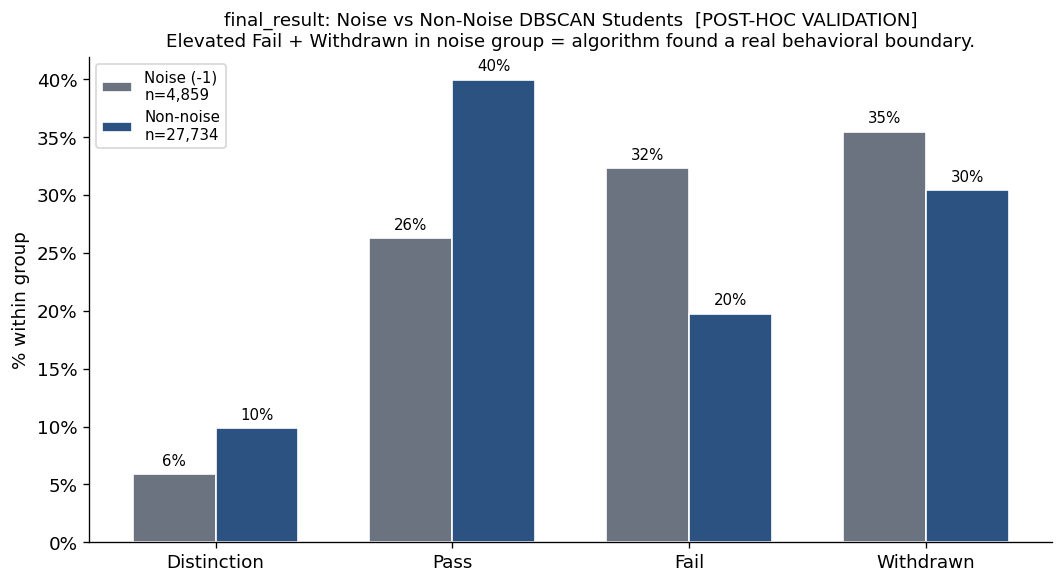

Saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\clustering\dbscan\dbscan_noise_outcomes.png

Raw comparison table:
              Noise (-1)\nn=4,859  Non-noise\nn=27,734
final_result                                          
Distinction                   5.9                  9.9
Pass                         26.3                 40.0
Fail                         32.3                 19.8
Withdrawn                    35.5                 30.4


In [35]:
# ── Plot 2: Outcome bar — noise vs non-noise ──────────────────────────────────
def outcome_share(df: pd.DataFrame) -> pd.Series:
    """Compute percentage of each final_result category within a group."""
    return (
        df["final_result"]
        .value_counts(normalize=True)
        .reindex(OUTCOME_ORDER, fill_value=0)
        * 100
    )

noise_share     = outcome_share(master[master["cluster_dbscan"] == -1])
non_noise_share = outcome_share(master[master["cluster_dbscan"] >= 0])

compare = pd.DataFrame({
    f"Noise (-1)\nn={n_noise:,}": noise_share,
    f"Non-noise\nn={int((cluster_dbscan >= 0).sum()):,}": non_noise_share,
})

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(OUTCOME_ORDER))
width = 0.35

bars_noise = ax.bar(
    x - width / 2, compare.iloc[:, 0], width,
    label=compare.columns[0],
    color="#6b7280", edgecolor="white",
)
bars_non = ax.bar(
    x + width / 2, compare.iloc[:, 1], width,
    label=compare.columns[1],
    color="#2c5282", edgecolor="white",
)

# Add value labels on bars
for bars in [bars_noise, bars_non]:
    for bar in bars:
        h = bar.get_height()
        if h >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f"{h:.0f}%",
                ha="center", va="bottom", fontsize=9,
            )

ax.set_xticks(x)
ax.set_xticklabels(OUTCOME_ORDER)
ax.set_ylabel("% within group")
ax.set_title(
    "final_result: Noise vs Non-Noise DBSCAN Students  [POST-HOC VALIDATION]\n"
    "Elevated Fail + Withdrawn in noise group = algorithm found a real behavioral boundary.",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
noise_out_path = FIGURES / "dbscan_noise_outcomes.png"
plt.savefig(noise_out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {noise_out_path}")
print("\nRaw comparison table:")
print(compare.round(1).to_string())

#### Visualization Insights

**PCA scatter:** The grey noise points are scattered across all regions — not 
concentrated in one area. This confirms they represent multiple types of outlier 
behavior, not just one extreme profile. The four colored clusters show clear 
spatial separation, particularly Cluster 1 (red, bottom-left = low engagement) 
and Cluster 0 (blue, right = high engagement).

**Outcome bar chart:** Noise students have 32% Fail + 35% Withdrawn = **67.8% at-risk** 
vs 50.2% for non-noise — a +17.6pp difference. The gap is most visible in the 
Fail bar (32% vs 20%) confirming the noise label captures genuinely struggling students.

**Note on PCA overlap:** Clusters 2 (pink) and 3 (cyan) overlap heavily with 
Cluster 0 (blue) in 2D — but their centroids show very different behavioral 
signatures in the full 17-feature space (see heatmap below).

## 8 — Interpret Non-Noise Clusters

We compute centroids for the dense DBSCAN clusters (excluding noise) in original feature units. This lets us describe the behavioral profile of each cluster in human-readable terms.

In [36]:
def compute_dbscan_centroids(
    X: np.ndarray,
    labels: np.ndarray,
    scaler,
    feature_cols: list,
) -> pd.DataFrame:
    """
    Compute centroids for non-noise DBSCAN clusters in original units.
    Noise points (label -1) are excluded — they have no meaningful centroid.
    """
    rows, idx = [], []
    for c in sorted(np.unique(labels)):
        if c < 0:
            continue  # skip noise
        mask           = labels == c
        centroid_scaled = X[mask].mean(axis=0)
        centroid_orig  = scaler.inverse_transform(centroid_scaled.reshape(1, -1))[0]
        rows.append(centroid_orig)
        idx.append(c)
    return pd.DataFrame(rows, index=idx, columns=feature_cols)


unique_non_noise = [c for c in np.unique(cluster_dbscan) if c >= 0]

if len(unique_non_noise) == 0:
    print("No non-noise clusters to interpret — adjust eps.")
else:
    centroids_db = compute_dbscan_centroids(X_scaled, cluster_dbscan, scaler, FEATURE_COLS)
    global_mean  = master[FEATURE_COLS].mean()
    global_std   = master[FEATURE_COLS].std()

    print("=" * 65)
    print("  DBSCAN Non-Noise Cluster Profiles (original units)")
    print("=" * 65)

    for c in centroids_db.index:
        row       = centroids_db.loc[c]
        n_in      = int((cluster_dbscan == c).sum())
        pct       = n_in / len(cluster_dbscan) * 100

        # Top 5 features that deviate most from dataset average
        diff     = (row - global_mean).abs().sort_values(ascending=False)
        top_feats = diff.head(5).index.tolist()

        # Post-hoc outcome for this cluster
        fail_withdrawn = (
            master[master["cluster_dbscan"] == c]["final_result"]
            .isin(["Fail", "Withdrawn"]).mean() * 100
        )

        print(f"\n{'─'*65}")
        print(f"  Cluster {c}  ({n_in:,} students, {pct:.1f}% of cohort)")
        print(f"  Fail/Withdrawn rate: {fail_withdrawn:.1f}%  [post-hoc]")
        print(f"  Top distinguishing features:")
        for feat in top_feats:
            val       = row[feat]
            avg       = global_mean[feat]
            direction = "↑ above" if val > avg else "↓ below"
            print(f"    {feat:<38} = {val:>8.3f}   (avg: {avg:.3f})  {direction}")

    print(f"\n{'='*65}")
    print(f"\nNoise students (-1): {n_noise:,} ({noise_pct:.1f}%) — extreme at-risk watchlist")
    noise_fw = (
        master[master["cluster_dbscan"] == -1]["final_result"]
        .isin(["Fail", "Withdrawn"]).mean() * 100
    )
    print(f"Noise Fail/Withdrawn rate: {noise_fw:.1f}%  [post-hoc]")

  DBSCAN Non-Noise Cluster Profiles (original units)

─────────────────────────────────────────────────────────────────
  Cluster 0  (20,201 students, 62.0% of cohort)
  Fail/Withdrawn rate: 35.0%  [post-hoc]
  Top distinguishing features:
    weighted_avg_score                     =   64.442   (avg: 50.187)  ↑ above
    registration_lead_days                 =   63.406   (avg: 69.404)  ↓ below
    total_clicks_log                       =    6.792   (avg: 5.706)  ↑ above
    score_trend_slope                      =   -1.299   (avg: -0.963)  ↓ below
    submission_timing                      =  -10.470   (avg: -10.775)  ↑ above

─────────────────────────────────────────────────────────────────
  Cluster 1  (5,679 students, 17.4% of cohort)
  Fail/Withdrawn rate: 100.0%  [post-hoc]
  Top distinguishing features:
    weighted_avg_score                     =    0.000   (avg: 50.187)  ↓ below
    registration_lead_days                 =   79.471   (avg: 69.404)  ↑ above
    total_clicks_log

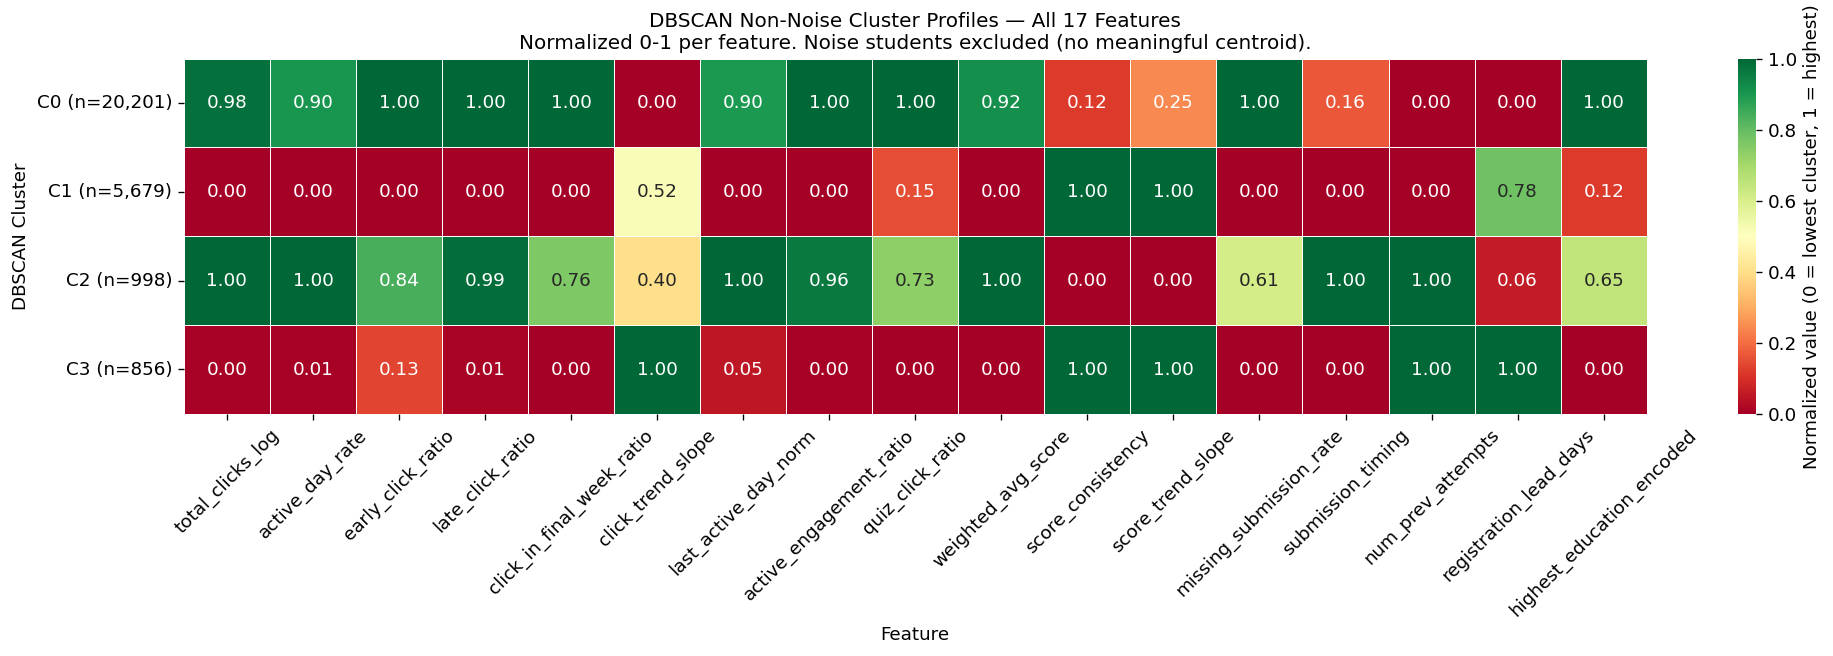

Saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\clustering\dbscan\cluster_heatmap_dbscan.png


In [37]:
# ── Cluster Feature Heatmap (non-noise clusters only) ─────────────────────────
if len(unique_non_noise) >= 2:
    col_min   = centroids_db.min(axis=0)
    col_max   = centroids_db.max(axis=0)
    col_range = (col_max - col_min).replace(0, 1)
    heatmap_norm = (centroids_db - col_min) / col_range

    heatmap_norm.index = [f"C{c} (n={int((cluster_dbscan==c).sum()):,})" for c in heatmap_norm.index]

    fig, ax = plt.subplots(figsize=(17, max(4, len(unique_non_noise) * 1.4)))
    sns.heatmap(
        heatmap_norm,
        ax=ax,
        cmap="RdYlGn",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.4,
        cbar_kws={"label": "Normalized value (0 = lowest cluster, 1 = highest)"},
    )
    ax.set_title(
        "DBSCAN Non-Noise Cluster Profiles — All 17 Features\n"
        "Normalized 0-1 per feature. Noise students excluded (no meaningful centroid).",
        fontsize=12,
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("DBSCAN Cluster")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    heatmap_db_path = FIGURES / "cluster_heatmap_dbscan.png"
    plt.savefig(heatmap_db_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {heatmap_db_path}")
else:
    print("Only one non-noise cluster — heatmap skipped (needs at least 2 clusters to compare).")

#### Cluster Interpretation Insights

Reading the centroid values and heatmap:

- **C0 (20,201 students — 62%):** High score (64.4), high clicks, active until late. 
  35% at-risk rate — the broad "passing" majority. Matches HC's Consistent Learner.

- **C1 (5,679 students — 17.4%):** Score = 0, clicks near zero, 100% Failed/Withdrawn. 
  Completely disengaged. Matches HC's Disengaged/Withdrawn perfectly.

- **C2 (998 students — 3.1%):** Highest score (70.4), high engagement, but 
  `num_prev_attempts = 1.0` — these are **repeat students who are finally succeeding**. 
  An interesting profile not clearly visible in notebook 04.

- **C3 (856 students — 2.6%):** Score = 0, near-zero clicks, 99.9% Failed/Withdrawn. 
  Very similar to C1 but distinct enough for DBSCAN to separate — likely differ in 
  `registration_lead_days` (83.9 vs 79.5) suggesting slightly different withdrawal timing.

- **Noise (4,859 students — 14.9%):** 67.8% at-risk. Behaviorally ambiguous students 
  who don't fit cleanly into any dense group — the highest-priority intervention target.

**Intervention priority:**
1. Noise (-1) — ambiguous outliers, contact weeks 1-2
2. C1 + C3 — confirmed disengaged (100% at-risk), contact immediately
3. C0 students with declining click_trend_slope — monitor for mid-module drop-off

## 9 — Save Outputs for Notebook 07

We add `cluster_dbscan` to `master_with_clusters.csv`. Cluster columns from prior notebooks use `(code_module, code_presentation, id_student)` — not `id_student` alone.

In [38]:
# Save updated master_with_clusters.csv
# master already has cluster_dbscan attached from section 4
master.to_csv(mwc_path, index=False)

print(f"Saved → {mwc_path}")
print(f"Shape  : {master.shape}")

cluster_cols = [c for c in master.columns if c.startswith("cluster_") or c.endswith("_profile")]
print(f"Cluster columns: {cluster_cols}")

print("\n── Sample output ──")
display_cols = ["id_student", "final_result", "cluster_dbscan"] + \
               [c for c in ["cluster_hc", "hc_profile", "cluster_kmeans"] if c in master.columns]
print(master[display_cols].head(8).to_string(index=False))

Saved → D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\data\processed\master_with_clusters.csv
Shape  : (32593, 24)
Cluster columns: ['cluster_hc', 'hc_profile', 'cluster_dbscan']

── Sample output ──
 id_student final_result  cluster_dbscan  cluster_hc             hc_profile
      11391         Pass               0           0     Consistent Learner
      28400         Pass               0           0     Consistent Learner
      30268    Withdrawn               1           1 Disengaged / Withdrawn
      31604         Pass               0           0     Consistent Learner
      32885         Pass               0           0     Consistent Learner
      38053         Pass               0           0     Consistent Learner
      45462         Pass               0           0     Consistent Learner
      45642         Pass              -1           0     Consistent Learner


## Summary

| Output | Location |
|--------|----------|
| Trained model | `models/dbscan_model.pkl` |
| Cluster labels | `data/processed/master_with_clusters.csv` → column `cluster_dbscan` |
| k-NN distance plot | `figures/clustering/dbscan/dbscan_knn_plot.png` |
| PCA scatter | `figures/clustering/dbscan/pca_clusters_dbscan.png` |
| Noise outcome bar | `figures/clustering/dbscan/dbscan_noise_outcomes.png` |
| Feature heatmap | `figures/clustering/dbscan/cluster_heatmap_dbscan.png` |

**Key results:**
- 4 meaningful clusters + 4,859 noise students (14.9% of cohort)
- Noise Fail+Withdrawn rate: 67.8% vs 50.2% non-noise (+17.6pp) ✓
- C1 + C3: 100% and 99.9% at-risk — confirmed disengaged profiles
- C2: repeat students finally succeeding (num_prev_attempts = 1.0) — unique finding
- ARI vs Hierarchical: 0.39 — moderate agreement, as expected

**The DBSCAN difference:**  
Some students labeled Consistent Learner by Hierarchical were flagged as noise 
by DBSCAN — meaning they sit on behavioral boundaries that partition-based methods 
smooth over. These borderline students are the most valuable addition to the 
at-risk watchlist beyond what notebook 04 already found.

**Next step:** Run `06_gmm_clustering.ipynb`, then `07_model_comparison.ipynb`.